# Questão 2 — Gestão de Consumo de Energia

Objetivo: achar o intervalo de tempo **contínuo** com maior **criticidade acumulada**,
comparando força bruta e divide-and-conquer. Este notebook só chama o que já está em
`src/` e narra os resultados — nenhuma lógica é reimplementada aqui.

**Dataset**: 1.200 leituras sintéticas (10 dias × 5 regiões), com um evento crítico
injetado de propósito (a região Sul teve a capacidade cortada pela metade por 30h),
pra existir um período realmente pior que o resto pros algoritmos acharem.

In [1]:
# roda a partir da raiz do repositorio, onde ficam src/, data/ e figures/
import os
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

from src.estruturas import carregar_leituras, agrupar_por_regiao, regioes_existentes, maiores_picos_de_consumo

leituras = carregar_leituras()
print(f"{len(leituras)} leituras carregadas de data/problema2.csv")
print(f"regioes: {sorted(regioes_existentes(leituras))}")

1200 leituras carregadas de data/problema2.csv
regioes: ['Centro', 'Leste', 'Norte', 'Oeste', 'Sul']


## Estruturas de dados (Parte A)

Agrupar por região (dict), listar regiões (set) e achar os maiores picos de consumo (heap).

In [2]:
por_regiao = agrupar_por_regiao(leituras)
for regiao, leituras_da_regiao in por_regiao.items():
    print(f"{regiao}: {len(leituras_da_regiao)} leituras")

print()
print("5 maiores picos de consumo do dataset inteiro:")
for leitura in maiores_picos_de_consumo(leituras, 5):
    print(f"  {leitura['timestamp']}  {leitura['regiao']:7s}  consumo={leitura['consumo']}")

Norte: 240 leituras
Sul: 240 leituras
Leste: 240 leituras
Oeste: 240 leituras
Centro: 240 leituras

5 maiores picos de consumo do dataset inteiro:
  2025-06-07 08:00:00  Centro   consumo=617.07
  2025-06-09 19:00:00  Centro   consumo=615.34
  2025-06-05 21:00:00  Centro   consumo=595.01
  2025-06-10 07:00:00  Centro   consumo=594.83
  2025-06-03 06:00:00  Centro   consumo=591.59


## Força bruta vs divide-and-conquer (Partes B e C)

Os dois recebem a mesma lista de leituras e devem achar o mesmo intervalo crítico.

In [3]:
import time

from src.brute_force import buscar_intervalo_critico_forca_bruta
from src.divide_conquer import buscar_intervalo_critico_divide_conquer

inicio_t = time.perf_counter()
fb_inicio, fb_fim, fb_criticidade = buscar_intervalo_critico_forca_bruta(leituras)
tempo_fb = time.perf_counter() - inicio_t

inicio_t = time.perf_counter()
dc_inicio, dc_fim, dc_criticidade = buscar_intervalo_critico_divide_conquer(leituras)
tempo_dc = time.perf_counter() - inicio_t

print(f"forca bruta:        indices [{fb_inicio},{fb_fim}]  criticidade={fb_criticidade:.2f}  tempo={tempo_fb:.4f}s")
print(f"divide-and-conquer:  indices [{dc_inicio},{dc_fim}]  criticidade={dc_criticidade:.2f}  tempo={tempo_dc:.4f}s")
print()
print(f"mesma resposta? {(fb_inicio, fb_fim) == (dc_inicio, dc_fim)}")
print()
print(f"periodo critico encontrado: {leituras[fb_inicio]['timestamp']} a {leituras[fb_fim]['timestamp']}")

forca bruta:        indices [571,586]  criticidade=1873.20  tempo=0.0338s
divide-and-conquer:  indices [571,586]  criticidade=1873.20  tempo=0.0021s

mesma resposta? True

periodo critico encontrado: 2025-06-05 18:00:00 a 2025-06-05 21:00:00


## Figura 1 — série temporal com o intervalo crítico destacado

figura salva em figures/questao2/serie_temporal.png
intervalo critico destacado: 2025-06-05 18:00:00 a 2025-06-05 21:00:00 (criticidade 1873.2)


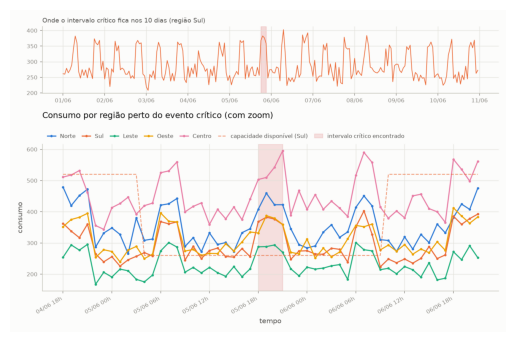

In [4]:
import matplotlib.pyplot as plt

from src.grafico_serie_temporal import gerar_figura as gerar_figura_serie_temporal

gerar_figura_serie_temporal()
plt.imshow(plt.imread("figures/questao2/serie_temporal.png"))
plt.axis("off")
plt.show()

## Figura 2 — árvore de decomposição do divide-and-conquer

Construída em cima do intervalo crítico real achado acima. Contorno vermelho = caminho vencedor.

figura salva em figures/questao2/arvore_decomposicao.png
niveis da arvore: 5
resultado no topo: [571,586] criticidade 1873.2


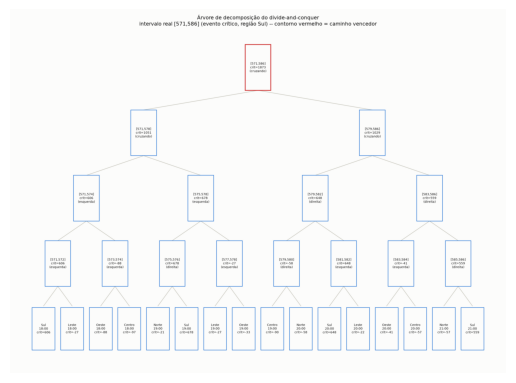

In [5]:
from src.grafico_arvore_decomposicao import gerar_figura as gerar_figura_arvore

gerar_figura_arvore()
plt.imshow(plt.imread("figures/questao2/arvore_decomposicao.png"))
plt.axis("off")
plt.show()

## Experimento de escalabilidade (Parte D)

Roda os dois algoritmos pra n = 100 até 5.000, medindo tempo, operações e memória.

In [6]:
from src.experimento_escalabilidade import rodar_experimento, salvar_resultados

resultados = rodar_experimento()
salvar_resultados(resultados)

print()
print(f"{'n':>6} | {'forca bruta (s)':>16} | {'divide-conquer (s)':>19} | {'ops forca bruta':>15} | {'ops divide-conquer':>19}")
for linha in resultados:
    print(
        f"{linha['n']:>6} | {linha['tempo_forca_bruta_s']:>16.6f} | {linha['tempo_divide_conquer_s']:>19.6f} | "
        f"{linha['operacoes_forca_bruta']:>15} | {linha['operacoes_divide_conquer']:>19}"
    )

n=100: forca bruta 0.0002s | divide-and-conquer 0.0001s
n=250: forca bruta 0.0014s | divide-and-conquer 0.0004s
n=500: forca bruta 0.0057s | divide-and-conquer 0.0008s


n=1000: forca bruta 0.0249s | divide-and-conquer 0.0019s


n=2000: forca bruta 0.1133s | divide-and-conquer 0.0038s


n=5000: forca bruta 0.6115s | divide-and-conquer 0.0104s
resultados salvos em data/escalabilidade.csv

     n |  forca bruta (s) |  divide-conquer (s) | ops forca bruta |  ops divide-conquer
   100 |         0.000217 |            0.000150 |            5050 |                 664
   250 |         0.001398 |            0.000398 |           31375 |                1991
   500 |         0.005692 |            0.000830 |          125250 |                4483
  1000 |         0.024924 |            0.001853 |          500500 |                9966
  2000 |         0.113311 |            0.003760 |         2001000 |               21932
  5000 |         0.611495 |            0.010442 |        12502500 |               61439


## Figura 3 — escalabilidade (força bruta vs divide-and-conquer)

figura salva em figures/questao2/escalabilidade.png

interpretacao:
O tempo medido acompanha a analise assintotica esperada. Quando o tamanho da entrada cresce 50 vezes (de 100 para 5.000 leituras), o tempo da forca bruta cresce cerca de 2.554 vezes -- proximo de 50^2 = 2.500, exatamente o comportamento esperado de um algoritmo O(n^2). Ja o divide-and-conquer cresceu so ~62 vezes no mesmo intervalo, compativel com O(n log n): o log(n) cresce bem devagar (log2(100) ~ 6,6 e log2(5000) ~ 12,3), entao o crescimento fica dominado pelo proprio n, nao pelo seu quadrado. Pra datasets pequenos a diferenca e irrelevante (0,2ms vs 0,16ms pra n=100), mas a partir de alguns milhares de leituras a forca bruta ja fica visivelmente mais lenta -- e com n=1.000.000 ela se tornaria inviavel, enquanto o divide-and-conquer continuaria rapido.


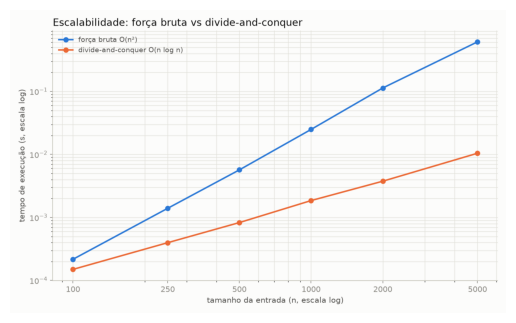

O tempo medido acompanha a analise assintotica esperada. Quando o tamanho da entrada cresce 50 vezes (de 100 para 5.000 leituras), o tempo da forca bruta cresce cerca de 2.554 vezes -- proximo de 50^2 = 2.500, exatamente o comportamento esperado de um algoritmo O(n^2). Ja o divide-and-conquer cresceu so ~62 vezes no mesmo intervalo, compativel com O(n log n): o log(n) cresce bem devagar (log2(100) ~ 6,6 e log2(5000) ~ 12,3), entao o crescimento fica dominado pelo proprio n, nao pelo seu quadrado. Pra datasets pequenos a diferenca e irrelevante (0,2ms vs 0,16ms pra n=100), mas a partir de alguns milhares de leituras a forca bruta ja fica visivelmente mais lenta -- e com n=1.000.000 ela se tornaria inviavel, enquanto o divide-and-conquer continuaria rapido.


In [7]:
from src.grafico_escalabilidade import gerar_figura as gerar_figura_escalabilidade, INTERPRETACAO

gerar_figura_escalabilidade()
plt.imshow(plt.imread("figures/questao2/escalabilidade.png"))
plt.axis("off")
plt.show()

print(INTERPRETACAO)

## Análise Big-O (resumo)

Completa em `docs/analise_complexidade.md`. Resumo:

- **Força bruta**: T(n) = O(n²), S(n) = O(n).
- **Divide-and-conquer**: T(n) = O(n log n), S(n) = O(n).
- De 1.000 pra 1.000.000 de registros: só o divide-and-conquer continua viável.

## Conclusão

Os dois algoritmos chegam no mesmo intervalo crítico — a diferença é o quanto cada um
demora conforme o dataset cresce. Essa diferença entre O(n²) e O(n log n) é o que
decide se a solução continua funcionando num sistema real.